In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, Model

# Download Dataset Bitcoin
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)
print("Data Berhasil Diunduh. Kolom:", df.columns.tolist())

Data Berhasil Diunduh. Kolom: ['Date', 'Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']


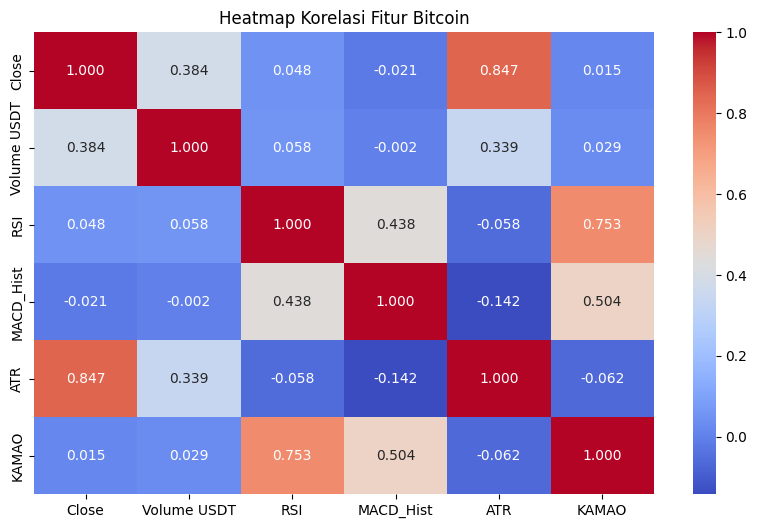

In [2]:
# Fix Datetime
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df.set_index('Date', inplace=True)

# Fitur Selection (Sesuai Bitcoin3.csv)
features = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
df_selected = df[features].copy().astype('float32')

# Heatmap Korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(df_selected.corr(), annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Heatmap Korelasi Fitur Bitcoin')
plt.show()

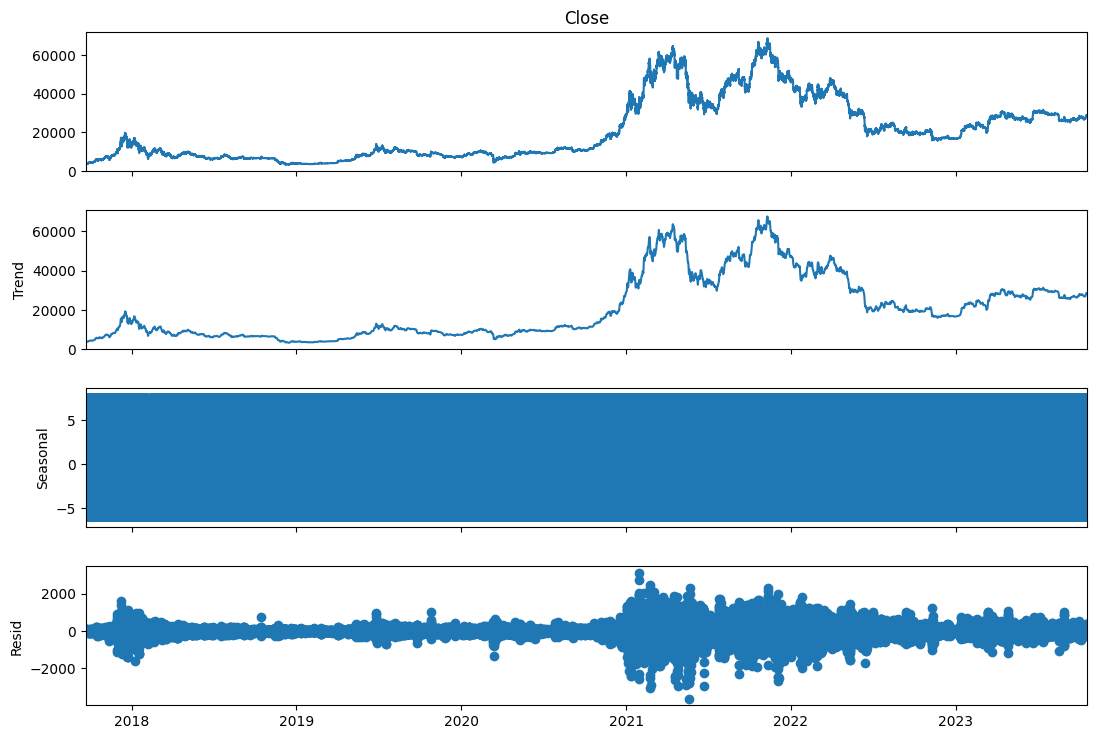

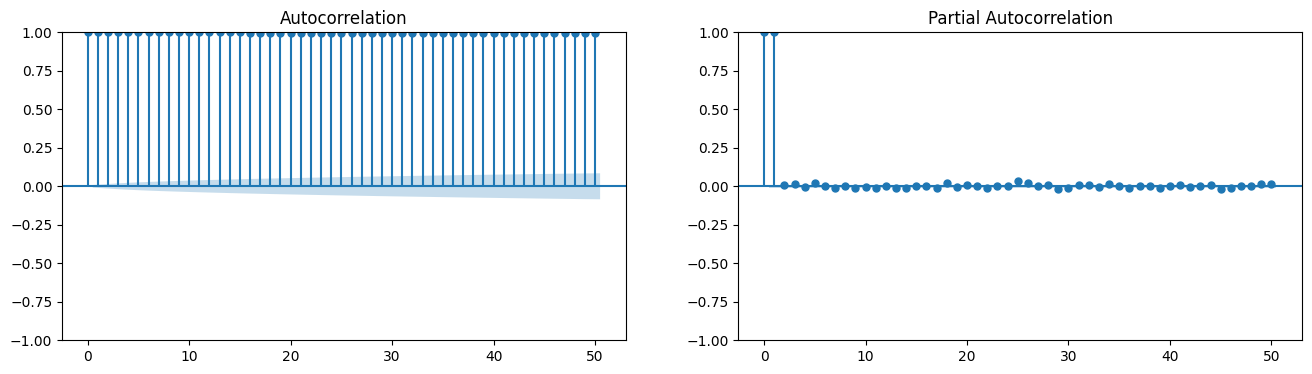

In [3]:
target_col = 'Close'

# Analisis Dekomposisi
decomposition = seasonal_decompose(df_selected[target_col], model='additive', period=24)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# Uji ACF & PACF untuk menentukan Window Size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_selected[target_col], lags=50, ax=ax1)
plot_pacf(df_selected[target_col], lags=50, ax=ax2)
plt.show()

In [4]:
# Rolling Statistic (Window 24 jam)
df_selected['Close_Rolling_Mean_24'] = df_selected['Close'].rolling(window=24).mean()
df_selected['Close_Rolling_Std_24'] = df_selected['Close'].rolling(window=24).std()
df_selected.dropna(inplace=True)

print("Fitur Akhir:", df_selected.columns.tolist())

Fitur Akhir: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'Close_Rolling_Mean_24', 'Close_Rolling_Std_24']


In [5]:
n = len(df_selected)
train_df = df_selected[0:int(n*0.7)]
val_df = df_selected[int(n*0.7):int(n*0.9)]
test_df = df_selected[int(n*0.9):]

scaler = MinMaxScaler()
scaler.fit(train_df) # Fit hanya pada training

train_scaled = scaler.transform(train_df).astype('float32')
val_scaled = scaler.transform(val_df).astype('float32')
test_scaled = scaler.transform(test_df).astype('float32')

target_index = df_selected.columns.get_loc('Close')

In [6]:
WINDOW_SIZE = 24
HORIZON = 24
BATCH_SIZE = 128

def create_windowed_dataset(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size, :])
        y.append(data[i + window_size : i + window_size + horizon, target_index])
    return np.array(X).astype('float32'), np.array(y).astype('float32')

X_train, y_train = create_windowed_dataset(train_scaled, WINDOW_SIZE, HORIZON)
X_val, y_val = create_windowed_dataset(val_scaled, WINDOW_SIZE, HORIZON)
X_test, y_test = create_windowed_dataset(test_scaled, WINDOW_SIZE, HORIZON)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Dataset Ready. X_train shape: {X_train.shape}")

Dataset Ready. X_train shape: (37141, 24, 8)


In [7]:
class MyCustomDense(layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units), initializer="random_normal", trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True)

    def call(self, inputs):
        x = tf.matmul(inputs, self.w) + self.b
        return self.activation(x) if self.activation else x

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units,
            "activation": tf.keras.activations.serialize(self.activation),
        })
        return config

class MyCustomAttention(layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads # Simpan parameter
        self.key_dim = key_dim     # Simpan parameter
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        self.layernorm = layers.LayerNormalization()
        self.add = layers.Add()

    def call(self, inputs):
        attn_output = self.mha(query=inputs, value=inputs, key=inputs)
        return self.layernorm(self.add([inputs, attn_output]))

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "key_dim": self.key_dim,
        })
        return config

class MyCustomDropout(layers.Layer):
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        return tf.nn.dropout(inputs, rate=self.rate) if training else inputs

    def get_config(self):
        config = super().get_config()
        config.update({"rate": self.rate})
        return config

In [8]:
def build_baseline(input_shape, horizon):
    # Definisi Input
    inputs = layers.Input(shape=input_shape)

    # LSTM Layer
    x = layers.LSTM(64, return_sequences=True)(inputs)

    # Menggunakan Custom Attention dari Sel 7
    x = MyCustomAttention(num_heads=2, key_dim=64)(x)

    # Global Average Pooling untuk mereduksi dimensi temporal
    x = layers.GlobalAveragePooling1D()(x)

    # Menggunakan Custom Dense dari Sel 7
    x = MyCustomDense(32, activation='relu')(x)

    # Output Layer (24 langkah ke depan)
    outputs = MyCustomDense(horizon)(x)

    # Inisialisasi Model dengan nama sesuai syarat
    model = Model(inputs=inputs, outputs=outputs, name="model_baseline_LSTM")
    return model

# Inisialisasi dan Pembuatan Objek Model
input_shape_baseline = (WINDOW_SIZE, X_train.shape[-1])
model_baseline = build_baseline(input_shape_baseline, HORIZON)

# Menampilkan Ringkasan Model
model_baseline.summary()

Model: "model_baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_custom_attention             │ (None, 24, 64)         │        33,344 │
│ (MyCustomAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_custom_dense (MyCustomDense) │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_custom_dense_1               │ (None, 24)             │           792 │
│ (MyCustomDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,904 (214.47 KB)

 Trainable params: 54,904 (214.47 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# TRAINING MODEL BASELINE DENGAN model.fit()

print("Memulai proses training model LSTM Baseline...")

# Kompilasi model
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mae'
)

# Callback standar
early_stop_baseline = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Proses Training menggunakan .fit()
history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop_baseline]
)

# Simpan model setelah .fit() selesai
model_baseline.save('model_baseline_LSTM.keras')
print("Training Baseline selesai dan model disimpan!")

Memulai proses training model LSTM Baseline...
Epoch 1/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0213 - val_loss: 0.0283
Epoch 2/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0170 - val_loss: 0.0193
Epoch 3/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0108 - val_loss: 0.0216
Epoch 4/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0115 - val_loss: 0.0191
Epoch 5/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0105 - val_loss: 0.0163
Epoch 6/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0099 - val_loss: 0.0160
Epoch 7/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0094 - val_loss: 0.0138
Epoch 8/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0098 - val_loss: 0.0119
Epoch 9/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0090 - val_loss: 0.0220
Epoch 10/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0086 - val_loss: 0.0096
Epoch 11/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0083 - val_loss: 0.0126


In [10]:
class Seq2SeqLSTM(Model):
    def __init__(self, units, horizon, **kwargs):
        super(Seq2SeqLSTM, self).__init__(**kwargs)
        self.units = units
        self.horizon = horizon
        self.encoder_lstm = layers.LSTM(units, return_state=True)
        self.decoder_lstm = layers.LSTM(units, return_sequences=True, return_state=True)
        self.attention = MyCustomAttention(num_heads=2, key_dim=units)

        self.dropout = MyCustomDropout(rate=0.1)

        self.output_layer = MyCustomDense(1)

    def call(self, inputs, training=None, teacher_forcing_target=None):
        _, state_h, state_c = self.encoder_lstm(inputs)
        states = [state_h, state_c]
        decoder_input = tf.expand_dims(inputs[:, -1, target_index:target_index+1], 1)

        all_outputs = []
        for t in range(self.horizon):
            x, state_h, state_c = self.decoder_lstm(decoder_input, initial_state=states)
            states = [state_h, state_c]

            x = self.attention(x)

            # Aplikasi Dropout
            x = self.dropout(x, training=training)

            prediction = self.output_layer(x)
            all_outputs.append(prediction)

            if training and teacher_forcing_target is not None:
                decoder_input = tf.expand_dims(teacher_forcing_target[:, t:t+1], -1)
            else:
                decoder_input = prediction

        final_output = tf.concat(all_outputs, axis=1)
        return tf.squeeze(final_output, axis=-1)

    def get_config(self):
        config = super(Seq2SeqLSTM, self).get_config()
        config.update({
            "units": self.units,
            "horizon": self.horizon,
        })
        return config

# Inisialisasi
model_seq2seq = Seq2SeqLSTM(units=128, horizon=HORIZON, name="model_seq2seq_LSTM")
dummy_input = tf.random.normal((1, WINDOW_SIZE, X_train.shape[-1]))
_ = model_seq2seq(dummy_input)
model_seq2seq.summary()

Model: "model_seq2seq_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ ((1, 128), (1, 128),   │        70,144 │
│                                 │ (1, 128))              │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ((1, 1, 128), (1,      │        66,560 │
│                                 │ 128), (1, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_custom_attention_1           │ ?                      │       132,224 │
│ (MyCustomAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_custom_dropout               │ ?                      │             0 │
│ (MyCustomDropout)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_custom_dense_2               │ ?                      │           129 │
│ (MyCustomDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,057 (1.03 MB)

 Trainable params: 269,057 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def weighted_mae_loss(y_true, y_pred):
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
    weights = tf.cast(tf.linspace(1.0, 2.0, HORIZON), tf.float32)
    return tf.reduce_mean(tf.abs(y_true - y_pred) * weights)

opt_baseline = tf.keras.optimizers.Adam(0.001)
opt_seq2seq = tf.keras.optimizers.Adam(learning_rate=0.001)
train_metric = tf.keras.metrics.Mean()
val_metric = tf.keras.metrics.Mean()

In [12]:
from tqdm.auto import tqdm
import time
import numpy as np
import tensorflow as tf

def train_loop(model, train_data, val_data, optimizer, epochs=60, target_loss=0.015):
    best_v_loss = float('inf')
    patience = 10
    wait = 0

    output_filename = f"{model.name}.keras"
    best_output_filename = f"best_{model.name}.keras"

    # Deteksi apakah ini model Seq2Seq
    is_seq2seq = "seq2seq" in model.name.lower()

    print(f"\n" + "="*50)
    print(f"MEMULAI PELATIHAN KUSTOM : {model.name}")
    print("="*50)

    @tf.function
    def train_step(x, y):
        with tf.GradientTape() as tape:
            if is_seq2seq:
                pred = model(x, training=True, teacher_forcing_target=y)
            else:
                pred = model(x, training=True)
            loss = weighted_mae_loss(y, pred)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    @tf.function
    def val_step(xv, yv):
        v_pred = model(xv, training=False)
        return weighted_mae_loss(yv, v_pred)

    for epoch in range(epochs):
        start_time = time.time()
        train_metric.reset_state()
        val_metric.reset_state()

        # FASE TRAINING
        train_pbar = tqdm(train_data, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for x, y in train_pbar:
            # Gunakan fungsi yang sudah dikompilasi
            loss = train_step(x, y)
            train_metric.update_state(loss)
            train_pbar.set_postfix({"loss": f"{train_metric.result():.4f}"})

        # FASE VALIDATION
        val_pbar = tqdm(val_data, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        for xv, yv in val_pbar:
            v_loss = val_step(xv, yv)
            val_metric.update_state(v_loss)
            val_pbar.set_postfix({"val_loss": f"{val_metric.result():.4f}"})

        v_loss_result = val_metric.result()
        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_metric.result():.4f} | Val Loss: {v_loss_result:.4f}")

        # Simpan versi model di epoch terakhir
        model.save(output_filename)

        # LOGIKA CHECKPOINT & EARLY STOPPING
        if v_loss_result < best_v_loss:
            best_v_loss = v_loss_result
            wait = 0

            if is_seq2seq:
                model.save(best_output_filename)
                print(f"  {best_output_filename} diperbarui!")
            else:
                print(f"  Model terbaik sementara disimpan!")

            # THRESHOLD TARGET
            if best_v_loss < target_loss:
                print(f"TARGET TERCAPAI!")
                break

        else:
            wait += 1
            if wait >= 3:
                old_lr = optimizer.learning_rate.numpy()
                optimizer.learning_rate.assign(old_lr * 0.5)
                print(f" Val loss stagnan.")

            if wait >= patience:
                print(f"\n Early stopping dipicu ({patience} epoch stagnan).")
                break

# EKSEKUSI PELATIHAN
train_loop(model_seq2seq, train_ds, val_ds, opt_seq2seq, epochs=60, target_loss=0.015)


MEMULAI PELATIHAN KUSTOM : model_seq2seq_LSTM


Epoch 1/60 [Train]:   0%|          | 0/291 [00:00<?, ?it/s]

Epoch 1/60 [Val]:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.0578 | Val Loss: 0.4736
  best_model_seq2seq_LSTM.keras diperbarui!


Epoch 2/60 [Train]:   0%|          | 0/291 [00:00<?, ?it/s]

...

Epoch 43/60 [Val]:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 43 | Train Loss: 0.0069 | Val Loss: 0.0173
  best_model_seq2seq_LSTM.keras diperbarui!


Epoch 44/60 [Train]:   0%|          | 0/291 [00:00<?, ?it/s]

Epoch 44/60 [Val]:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 44 | Train Loss: 0.0069 | Val Loss: 0.0138
  best_model_seq2seq_LSTM.keras diperbarui!
TARGET TERCAPAI!


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  

HASIL INFERENSI MODEL BASELINE LSTM


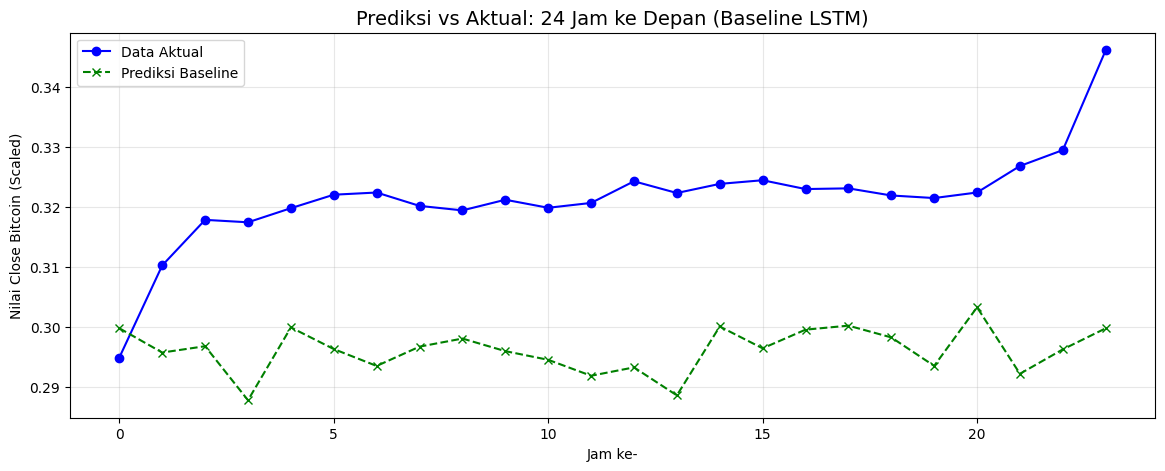

,Jam ke-,Data Aktual,Prediksi Baseline,Selisih (Error)
0,1,0.294945,0.299822,0.004877
1,2,0.310297,0.295774,0.014523
2,3,0.317891,0.296830,0.021061
3,4,0.317485,0.287828,0.029657
4,5,0.319837,0.299962,0.019875
5,6,0.322083,0.296355,0.025728
6,7,0.322446,0.293542,0.028905
7,8,0.320219,0.296759,0.023460
8,9,0.319469,0.298106,0.021363
9,10,0.321243,0.296008,0.025235



HASIL INFERENSI MODEL SEQ2SEQ LSTM


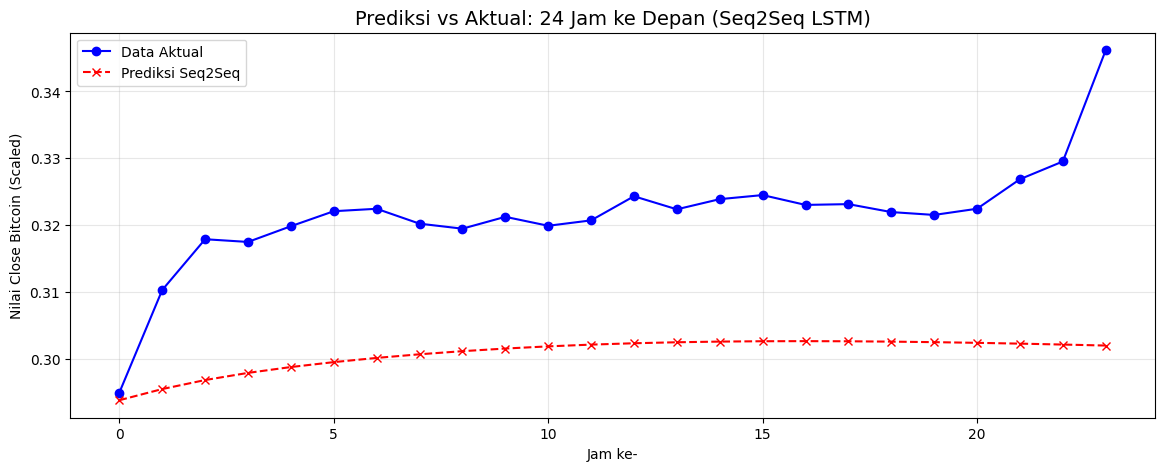

,Jam ke-,Data Aktual,Prediksi Seq2Seq,Selisih (Error)
0,1,0.294945,0.293808,0.001137
1,2,0.310297,0.295479,0.014818
2,3,0.317891,0.296827,0.021064
3,4,0.317485,0.297897,0.019588
4,5,0.319837,0.298772,0.021065
5,6,0.322083,0.299507,0.022576
6,7,0.322446,0.300137,0.022309
7,8,0.320219,0.300680,0.019539
8,9,0.319469,0.301145,0.018325
9,10,0.321243,0.301538,0.019705


HASIL AKHIR MAE DATA TEST (SEQ2SEQ): 0.00773


In [13]:
# SEL 12: INFERENCE, VISUALISASI KEDUA MODEL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ambil 1 batch dari data test untuk divisualisasikan
for x_test_sample, y_test_sample in test_ds.take(1):
    actual = y_test_sample[0].numpy()

    # Prediksi menggunakan Baseline LSTM (metode bawaan .predict)
    pred_baseline = model_baseline.predict(x_test_sample)[0]

    # Prediksi menggunakan Seq2Seq LSTM
    pred_seq2seq = model_seq2seq(x_test_sample, training=False)[0].numpy()

# VISUALISASI & TABEL MODEL BASELINE
print("\n" + "="*50)
print("HASIL INFERENSI MODEL BASELINE LSTM")
print("="*50)

plt.figure(figsize=(14, 5))
plt.plot(actual, label='Data Aktual', color='blue', marker='o')
plt.plot(pred_baseline, label='Prediksi Baseline', color='green', linestyle='--', marker='x')
plt.title('Prediksi vs Aktual: 24 Jam ke Depan (Baseline LSTM)', fontsize=14)
plt.xlabel('Jam ke-')
plt.ylabel('Nilai Close Bitcoin (Scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

df_baseline = pd.DataFrame({
    'Jam ke-': range(1, 25),
    'Data Aktual': actual,
    'Prediksi Baseline': pred_baseline,
    'Selisih (Error)': np.abs(actual - pred_baseline)
})
display(df_baseline)

# VISUALISASI & TABEL MODEL SEQ2SEQ
print("\n" + "="*50)
print("HASIL INFERENSI MODEL SEQ2SEQ LSTM")
print("="*50)

plt.figure(figsize=(14, 5))
plt.plot(actual, label='Data Aktual', color='blue', marker='o')
plt.plot(pred_seq2seq, label='Prediksi Seq2Seq', color='red', linestyle='--', marker='x')
plt.title('Prediksi vs Aktual: 24 Jam ke Depan (Seq2Seq LSTM)', fontsize=14)
plt.xlabel('Jam ke-')
plt.ylabel('Nilai Close Bitcoin (Scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

df_seq2seq = pd.DataFrame({
    'Jam ke-': range(1, 25),
    'Data Aktual': actual,
    'Prediksi Seq2Seq': pred_seq2seq,
    'Selisih (Error)': np.abs(actual - pred_seq2seq)
})
display(df_seq2seq)

# C. FINAL EVALUATION (MAE PADA DATA TEST)
all_mae_seq = []
for x_batch, y_batch in test_ds:
    preds = model_seq2seq(x_batch, training=False)
    mae_val = tf.reduce_mean(tf.abs(y_batch - preds))
    all_mae_seq.append(mae_val)

final_test_mae = np.mean(all_mae_seq)
print(f"="*50)
print(f"HASIL AKHIR MAE DATA TEST (SEQ2SEQ): {final_test_mae:.5f}")
print(f"="*50)

In [14]:
# Membuat berkas requirements.txt
!pip freeze > requirements.txt
print("Berkas requirements.txt berhasil dibuat!")

Berkas requirements.txt berhasil dibuat!
